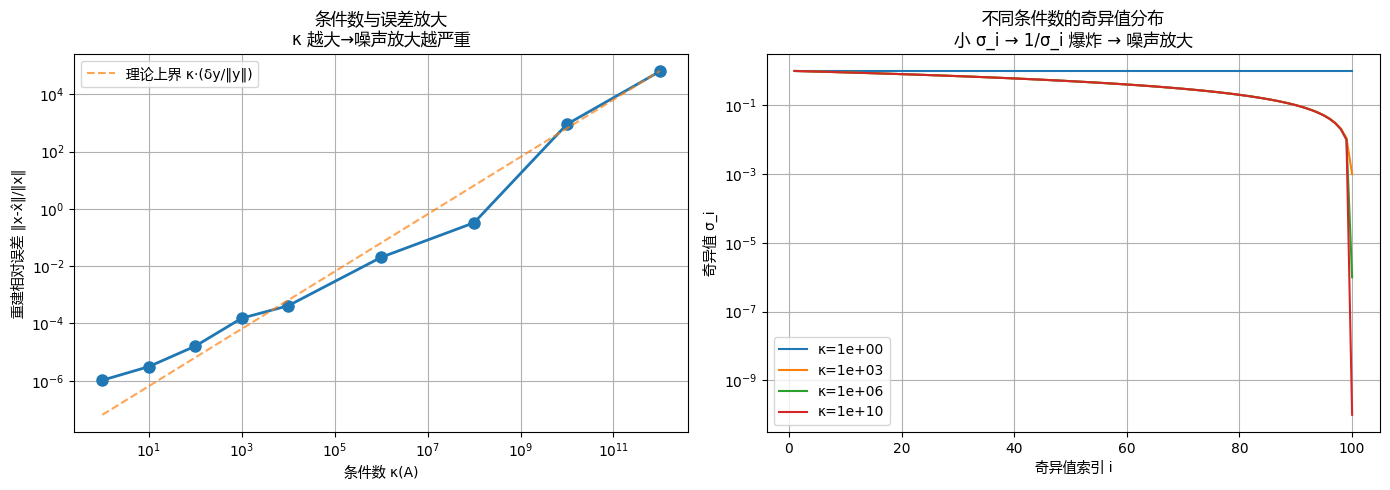

        κ(A)          相对误差
----------------------------
       1e+00    1.0435e-06
       1e+01    3.1118e-06
       1e+02    1.6170e-05
       1e+03    1.5244e-04
       1e+04    4.1490e-04
       1e+06    2.0329e-02
       1e+08    3.2715e-01
       1e+10    8.9816e+02
       1e+12    6.2951e+04


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ====== 解决中文乱码的核心代码 ======
plt.rcParams['font.family'] = ['DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================

np.random.seed(42)

# ---- 1. 构造不同条件数的对角矩阵 ----
n = 100
x_true = np.random.randn(n)

# 对角矩阵：最大奇异值=1，最小奇异值=1/κ
# 条件数从 1 到 10^12
kappas = [1, 10, 1e2, 1e3, 1e4, 1e6, 1e8, 1e10, 1e12]
noise_level = 1e-6  # 数据中的噪声水平

rel_errors = []

for kappa in kappas:
    # 构造对角矩阵 A：σ_1=1, σ_n=1/κ, 中间线性插值
    singular_values = np.linspace(1, 1.0 / kappa, n)

    # 正问题：y = Ax
    y = singular_values * x_true

    # 加入噪声
    y_noisy = y + noise_level * np.random.randn(n)

    # 逆问题：x = A^{-1} y_noisy
    x_recon = y_noisy / singular_values

    # 相对误差
    rel_err = np.linalg.norm(x_recon - x_true) / np.linalg.norm(x_true)
    rel_errors.append(rel_err)

# ---- 2. 可视化 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 重建误差 vs 条件数
axes[0].loglog(kappas, rel_errors, 'o-', linewidth=2, markersize=8)
axes[0].loglog(kappas, [kappa * noise_level / np.linalg.norm(x_true) * np.linalg.norm(singular_values * x_true) / np.linalg.norm(x_true)
                         for kappa in kappas], '--', alpha=0.7, label='理论上界 κ·(δy/‖y‖)')
axes[0].set_xlabel('条件数 κ(A)')
axes[0].set_ylabel('重建相对误差 ‖x-x̂‖/‖x‖')
axes[0].set_title('条件数与误差放大\nκ 越大→噪声放大越严重')
axes[0].legend()
axes[0].grid(True, which='both')

# 奇异值衰减示意
for kappa in [1, 1e3, 1e6, 1e10]:
    sv = np.linspace(1, 1.0 / kappa, n)
    axes[1].semilogy(np.arange(1, n + 1), sv, label=f'κ={kappa:.0e}')
axes[1].set_xlabel('奇异值索引 i')
axes[1].set_ylabel('奇异值 σ_i')
axes[1].set_title('不同条件数的奇异值分布\n小 σ_i → 1/σ_i 爆炸 → 噪声放大')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('实验1_6_条件数.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'κ(A)':>12s}  {'相对误差':>12s}")
print("-" * 28)
for kappa, err in zip(kappas, rel_errors):
    print(f"{kappa:12.0e}  {err:12.4e}")